# DQN: Deep Q-Learning with Experience Replay

This notebook implements a **Deep Q-Network (DQN)** from scratch and trains it to solve
the CartPole-v1 environment. DQN was the first deep RL algorithm to achieve human-level
performance on Atari games.

We will:
1. Review the RL framework: agents, environments, rewards, policies
2. Derive the Bellman equation and Q-learning update
3. Build a Q-Network (MLP) and experience replay buffer from scratch
4. Implement the full DQN algorithm with target network
5. Train on CartPole-v1 and visualize the learning process
6. Evaluate the trained agent

**Reference:** Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning.* Nature.
https://www.nature.com/articles/nature14236

In [ ]:
import sys, os

# In Colab, clone the repo so local imports (src/) work
if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/04_Reinforcement_Learning")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath('../..'))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque
from src.utils.device import set_seed

try:
    import gymnasium as gym
    print(f"Gymnasium version: {gym.__version__}")
except ImportError:
    print("Gymnasium not installed. Run: pip install -e '.[rl]'")


# DQN runs on CPU (fast enough for CartPole)
device = "cpu"
set_seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

## 1. What is Reinforcement Learning?

An **agent** interacts with an **environment** in a loop:

```
       ┌──────────────────────────────────────┐
       │                                      │
       ▼                                      │
  ┌─────────┐   action a_t   ┌─────────────┐ │
  │  Agent  │ ──────────────▶│ Environment │ │
  │ (policy)│                │ (CartPole)  │ │
  │         │ ◀──────────────│             │ │
  └─────────┘  state s_{t+1} └─────────────┘ │
       │       reward r_t                     │
       │                                      │
       └──────────────────────────────────────┘
```

At each timestep $t$:
1. Agent observes state $s_t$
2. Agent chooses action $a_t$ according to its **policy** $\pi$
3. Environment returns reward $r_t$ and next state $s_{t+1}$
4. Agent updates its policy to maximize cumulative reward

**Goal:** Find a policy $\pi^*$ that maximizes the expected cumulative discounted reward:

$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots = \sum_{k=0}^{\infty} \gamma^k r_{t+k}$

where $\gamma \in [0, 1)$ is the **discount factor** (how much we value future rewards).

## 2. Q-Learning

The **Q-function** $Q(s, a)$ estimates the expected return of taking action $a$ in state $s$
and then acting optimally:

$Q^*(s, a) = \mathbb{E}[r + \gamma \max_{a'} Q^*(s', a')]$

This is the **Bellman optimality equation**. If we know $Q^*$, the optimal policy is simply:

$\pi^*(s) = \arg\max_a Q^*(s, a)$

**Q-learning update** (tabular): $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$

**Problem:** A Q-table works for small discrete state spaces, but CartPole has a
4-dimensional continuous state (position, velocity, angle, angular velocity).
We need **function approximation**.

## 3. Deep Q-Networks

DQN approximates the Q-function with a neural network: $Q(s, a; \theta) \approx Q^*(s, a)$

Three key innovations from the Atari paper:

1. **Experience Replay** — store transitions in a buffer, sample random batches for training.
   Breaks correlation between consecutive samples and reuses data efficiently.

2. **Target Network** — use a frozen copy of the Q-network for computing targets.
   Prevents the "moving target" problem where the network chases its own predictions.

3. **Reward clipping** — clip rewards to $[-1, 1]$ for stability (not needed for CartPole).

**Loss function:**

$L(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right]$

where $\theta^-$ are the target network parameters (frozen, updated periodically).

In [4]:
# Explore the CartPole-v1 environment
env = gym.make("CartPole-v1")

print(f"State space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  Low:  {env.observation_space.low}")
print(f"  High: {env.observation_space.high}")
print(f"\nAction space: {env.action_space}")
print(f"  0 = push left, 1 = push right")

# Run a few random steps
state, _ = env.reset(seed=42)
print(f"\nInitial state: {state}")
print(f"  [cart_pos, cart_vel, pole_angle, pole_angular_vel]")

total_reward = 0
for step in range(20):
    action = env.action_space.sample()  # random action
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"\nRandom agent survived {step + 1} steps (reward: {total_reward})")
print(f"Max possible reward: 500 (episode truncates at 500 steps)")
env.close()

State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape: (4,)
  Low:  [-4.8               -inf -0.41887903        -inf]
  High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
  0 = push left, 1 = push right

Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
  [cart_pos, cart_vel, pole_angle, pole_angular_vel]

Random agent survived 20 steps (reward: 20.0)
Max possible reward: 500 (episode truncates at 500 steps)


## 4. Q-Network Architecture

For CartPole's 4D vector state, a simple MLP is sufficient:

```
State (4) → Linear(128) → ReLU → Linear(128) → ReLU → Q-values (2)
```

The network outputs a Q-value for **each action** simultaneously.
To select an action, we pick the one with the highest Q-value:
$a = \arg\max_a Q(s, a; \theta)$

Why not CNN? CartPole provides a compact state vector, not pixel observations.
The original Atari DQN used a CNN because it learned directly from screen pixels.

In [5]:
class QNetwork(nn.Module):
    """Simple MLP for Q-value approximation."""
    def __init__(self, state_size, action_size, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size),
        )

    def forward(self, x):
        return self.net(x)


# Demo
q_net = QNetwork(state_size=4, action_size=2)
state_tensor = torch.randn(1, 4)
q_values = q_net(state_tensor)
print(f"Input state shape: {state_tensor.shape}")
print(f"Output Q-values:   {q_values.detach().numpy()}")
print(f"Best action:       {q_values.argmax().item()}")
print(f"\nParameters: {sum(p.numel() for p in q_net.parameters()):,}")

Input state shape: torch.Size([1, 4])
Output Q-values:   [[-0.14969815  0.03438492]]
Best action:       1

Parameters: 17,410


## 5. Experience Replay

**Problem:** Training on consecutive transitions is unstable because:
- Consecutive states are highly correlated (violates i.i.d. assumption)
- Recent experience dominates, causing catastrophic forgetting

**Solution:** Store transitions $(s, a, r, s', \text{done})$ in a buffer.
Sample random mini-batches for training. This:
- Breaks temporal correlation
- Reuses each transition many times (data efficiency)
- Smooths the training distribution

In [6]:
class ReplayBuffer:
    """Fixed-size experience replay buffer with random sampling."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size, device="cpu"):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# Demo
buf = ReplayBuffer(capacity=100)
for i in range(50):
    buf.push(
        state=np.random.randn(4),
        action=random.randint(0, 1),
        reward=1.0,
        next_state=np.random.randn(4),
        done=False,
    )

states, actions, rewards, next_states, dones = buf.sample(8)
print(f"Buffer size: {len(buf)}")
print(f"Sampled batch shapes:")
print(f"  states:      {states.shape}")
print(f"  actions:     {actions.shape}")
print(f"  rewards:     {rewards.shape}")
print(f"  next_states: {next_states.shape}")
print(f"  dones:       {dones.shape}")

Buffer size: 50
Sampled batch shapes:
  states:      torch.Size([8, 4])
  actions:     torch.Size([8])
  rewards:     torch.Size([8])
  next_states: torch.Size([8, 4])
  dones:       torch.Size([8])


## 6. Epsilon-Greedy Exploration

**Explore vs exploit:** The agent needs to try new actions (explore) to discover better
strategies, but also use what it has learned (exploit) to maximize reward.

**$\epsilon$-greedy policy:**
- With probability $\epsilon$: take a **random** action (explore)
- With probability $1 - \epsilon$: take the **greedy** action $\arg\max_a Q(s, a)$ (exploit)

**Decay schedule:** Start with $\epsilon = 1.0$ (fully random) and decay to $\epsilon_{\min} = 0.01$
over training. Common decay: $\epsilon_t = \max(\epsilon_{\min}, \epsilon_{\text{start}} \cdot \epsilon_{\text{decay}}^t)$

## 7. The DQN Algorithm

**Pseudocode:**

```
Initialize Q-network θ, target network θ⁻ = θ, replay buffer D
For each episode:
    state = env.reset()
    For each step:
        action = ε-greedy(Q(state; θ))
        next_state, reward, done = env.step(action)
        D.push(state, action, reward, next_state, done)
        
        # Learn from replay buffer
        Sample batch (s, a, r, s', d) from D
        target = r + γ * max_a' Q(s', a'; θ⁻) * (1 - d)
        loss = MSE(Q(s, a; θ), target)
        Gradient descent on θ
        
        Every C steps: θ⁻ ← θ  (update target network)
        state = next_state
```

## 8. Target Network

**The moving target problem:** If we use the same network $Q(\cdot; \theta)$ for both
the prediction and the target, then updating $\theta$ changes the target too. This creates
a feedback loop that leads to divergence.

**Solution:** Maintain a separate **target network** $Q(\cdot; \theta^-)$ that is a frozen
copy of the Q-network. Update it periodically (every $C$ steps) by copying the weights.

**Target:** $y = r + \gamma \max_{a'} Q(s', a'; \theta^-)$ using the frozen target network.

**Loss:** $L = (y - Q(s, a; \theta))^2$ — only the online network $\theta$ receives gradients.

In [7]:
class DQNAgent:
    """DQN agent with experience replay and target network."""

    def __init__(self, state_size, action_size, hidden_size=128, lr=1e-3,
                 gamma=0.99, buffer_size=10000, batch_size=64,
                 target_update_freq=100, device="cpu"):
        self.action_size = action_size
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.device = device
        self.step_count = 0

        # Q-network and target network
        self.q_network = QNetwork(state_size, action_size, hidden_size).to(device)
        self.target_network = QNetwork(state_size, action_size, hidden_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()  # Target never trains

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(capacity=buffer_size)
        self.losses = []

    def select_action(self, state, epsilon):
        """Epsilon-greedy action selection."""
        if random.random() < epsilon:
            return random.randrange(self.action_size)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_values = self.q_network(state_t)
            return q_values.argmax().item()

    def learn(self):
        """Sample from replay buffer and perform one gradient step."""
        if len(self.replay_buffer) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(
            self.batch_size, self.device
        )

        # Current Q-values for chosen actions
        q_values = self.q_network(states)  # [batch, actions]
        q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)  # [batch]

        # Target Q-values from frozen target network
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1).values  # [batch]
            targets = rewards + self.gamma * next_q_values * (1 - dones)  # [batch]

        # MSE loss
        loss = nn.functional.mse_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.losses.append(loss.item())
        self.step_count += 1

        # Periodically update target network
        if self.step_count % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())


print("DQNAgent ready.")

DQNAgent ready.


In [8]:
def train_dqn(agent, env, num_episodes=500, epsilon_start=1.0, epsilon_end=0.01,
              epsilon_decay=0.995, print_every=50):
    """Train a DQN agent and return episode rewards."""
    rewards_history = []
    epsilon_history = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(state, action, reward, next_state, done)
            agent.learn()

            state = next_state
            episode_reward += reward

        rewards_history.append(episode_reward)
        epsilon_history.append(epsilon)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % print_every == 0:
            avg_reward = np.mean(rewards_history[-print_every:])
            print(f"Episode {episode+1:4d} | Avg reward: {avg_reward:6.1f} | "
                  f"Epsilon: {epsilon:.3f} | Buffer: {len(agent.replay_buffer)}")

    return rewards_history, epsilon_history


print("Training function ready.")

Training function ready.


## 9. Training

**Hyperparameters:**

| Parameter | Value | Description |
|---|---|---|
| Episodes | 500 | Number of training episodes |
| $\gamma$ (discount) | 0.99 | How much to value future rewards |
| Learning rate | $10^{-3}$ | Adam optimizer |
| Batch size | 64 | Replay buffer sample size |
| Buffer size | 10,000 | Replay buffer capacity |
| $\epsilon$ start/end | 1.0 / 0.01 | Exploration schedule |
| $\epsilon$ decay | 0.995 | Per-episode multiplicative decay |
| Target update | Every 100 steps | How often to copy Q → target |

In [9]:
# Train the agent
set_seed(42)
random.seed(42)
np.random.seed(42)

env = gym.make("CartPole-v1")

agent = DQNAgent(
    state_size=4,
    action_size=2,
    hidden_size=128,
    lr=1e-3,
    gamma=0.99,
    buffer_size=10000,
    batch_size=64,
    target_update_freq=100,
    device=device,
)

print("Training DQN on CartPole-v1...\n")
rewards, epsilons = train_dqn(
    agent, env,
    num_episodes=500,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    print_every=50,
)

env.close()
print(f"\nFinal avg reward (last 50): {np.mean(rewards[-50:]):.1f}")

Set seed for reproducibility: 42
Training DQN on CartPole-v1...

Episode   50 | Avg reward:   28.5 | Epsilon: 0.778 | Buffer: 1424
Episode  100 | Avg reward:   36.8 | Epsilon: 0.606 | Buffer: 3266
Episode  150 | Avg reward:   58.1 | Epsilon: 0.471 | Buffer: 6169
Episode  200 | Avg reward:  108.6 | Epsilon: 0.367 | Buffer: 10000
Episode  250 | Avg reward:  190.8 | Epsilon: 0.286 | Buffer: 10000
Episode  300 | Avg reward:  222.6 | Epsilon: 0.222 | Buffer: 10000
Episode  350 | Avg reward:  218.5 | Epsilon: 0.173 | Buffer: 10000
Episode  400 | Avg reward:  278.8 | Epsilon: 0.135 | Buffer: 10000
Episode  450 | Avg reward:  217.4 | Epsilon: 0.105 | Buffer: 10000
Episode  500 | Avg reward:  360.0 | Epsilon: 0.082 | Buffer: 10000

Final avg reward (last 50): 360.0


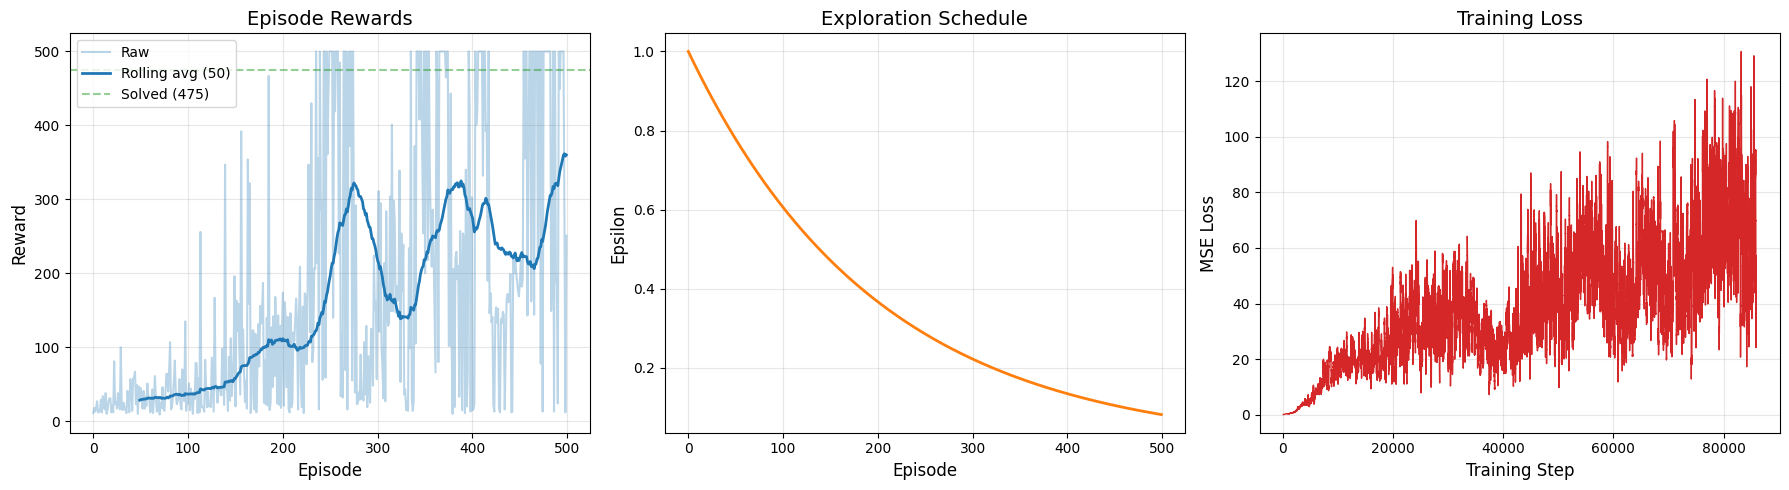

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Episode Rewards
ax = axes[0]
ax.plot(rewards, alpha=0.3, color='tab:blue', label='Raw')
window = 50
rolling_avg = pd.Series(rewards).rolling(window=window).mean()
ax.plot(rolling_avg, color='tab:blue', linewidth=2, label=f'Rolling avg ({window})')
ax.axhline(y=475, color='tab:green', linestyle='--', alpha=0.5, label='Solved (475)')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Episode Rewards', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Epsilon Decay
ax = axes[1]
ax.plot(epsilons, color='tab:orange', linewidth=2)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Epsilon', fontsize=12)
ax.set_title('Exploration Schedule', fontsize=14)
ax.grid(True, alpha=0.3)

# Plot 3: Training Loss
ax = axes[2]
if agent.losses:
    loss_smooth = pd.Series(agent.losses).rolling(window=100).mean()
    ax.plot(loss_smooth, color='tab:red', linewidth=1)
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training Loss', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Evaluate the trained agent (no exploration)
eval_env = gym.make("CartPole-v1")
eval_rewards = []

for ep in range(10):
    state, _ = eval_env.reset(seed=ep)
    episode_reward = 0
    done = False
    while not done:
        action = agent.select_action(state, epsilon=0.0)  # greedy
        state, reward, terminated, truncated, _ = eval_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    eval_rewards.append(episode_reward)
    print(f"Eval episode {ep+1}: reward = {episode_reward}")

eval_env.close()
print(f"\nAvg eval reward: {np.mean(eval_rewards):.1f} (solved >= 475)")

Eval episode 1: reward = 278.0
Eval episode 2: reward = 247.0
Eval episode 3: reward = 271.0
Eval episode 4: reward = 259.0
Eval episode 5: reward = 281.0
Eval episode 6: reward = 255.0
Eval episode 7: reward = 255.0
Eval episode 8: reward = 251.0
Eval episode 9: reward = 239.0
Eval episode 10: reward = 260.0

Avg eval reward: 259.6 (solved >= 475)


## 10. What "Solved" Means

CartPole-v1 is considered **solved** when the agent achieves an average reward of
$\geq 475$ over 100 consecutive episodes. The maximum possible reward per episode is 500
(the episode is truncated at 500 steps).

A well-tuned DQN typically solves CartPole within 200-400 episodes.

## 11. Reusable Implementation

The Q-Network and ReplayBuffer are available in `src/models/dqn.py`:

```python
from src.models.dqn import QNetwork, ReplayBuffer
```

In [ ]:
from src.models.dqn import QNetwork as QN, ReplayBuffer as RB

q = QN(state_size=4, action_size=2)
out = q(torch.randn(1, 4))
print(f"QNetwork output shape: {out.shape}")

b = RB(capacity=100)
b.push(np.zeros(4), 0, 1.0, np.zeros(4), False)
print(f"ReplayBuffer length: {len(b)}")
print("All src/ imports verified.")

## 12. Key Takeaways

1. **DQN approximates Q-values with a neural network.** Instead of a Q-table, we use an MLP that maps states to Q-values for all actions.

2. **Experience replay breaks temporal correlation.** Storing and randomly sampling transitions makes training stable and data-efficient.

3. **Target networks prevent the moving target problem.** A frozen copy of the Q-network provides stable targets. Updated periodically by copying weights.

4. **Epsilon-greedy balances exploration and exploitation.** High $\epsilon$ early for exploration, low $\epsilon$ later for exploitation.

5. **The Bellman equation is the foundation.** $Q(s,a) = r + \gamma \max_{a'} Q(s', a')$ — optimal Q-values satisfy this recursive relationship.

6. **DQN has known limitations:**
   - Overestimates Q-values (max operator is biased) → **Double DQN**
   - Uniform replay sampling is suboptimal → **Prioritized Experience Replay (PER)**
   - Single stream for state value and advantage → **Dueling DQN**

### Extensions (Future Notebooks)

| Method | Key Idea |
|---|---|
| Double DQN | Use online network to select action, target to evaluate |
| Dueling DQN | Separate value and advantage streams |
| PER | Prioritize transitions with high TD error |
| Rainbow | Combine all DQN improvements |
| PPO | Policy gradient method (next notebook) |

### Further Reading

- Mnih et al. (2015). *Human-level control through deep reinforcement learning.* https://www.nature.com/articles/nature14236
- Hasselt et al. (2016). *Deep Reinforcement Learning with Double Q-learning.* https://arxiv.org/abs/1509.06461
- OpenAI Spinning Up: https://spinningup.openai.com/